# 6. Анализ временных рядов

## Цели:
- Анализ трендов и сезонности продаж
- Выявление недельных и дневных паттернов
- Декомпозиция временных рядов
- Обнаружение аномалий и выбросов
- Подготовка данных для прогнозирования

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')

In [2]:
# Настройка путей
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.time_series_analyzer import TimeSeriesAnalyzer

In [3]:
# Установка необходимых библиотек (если не установлены)
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.tsa.stattools import acf, pacf
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    print("✓ statsmodels успешно импортирован")
except ImportError:
    print("❌ statsmodels не установлен. Устанавливаем...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])
    
    # Пробуем снова
    try:
        from statsmodels.tsa.seasonal import seasonal_decompose
        from statsmodels.tsa.stattools import acf, pacf
        from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
        print("✓ statsmodels успешно установлен и импортирован")
    except ImportError as e:
        print(f"❌ Не удалось установить statsmodels: {e}")

✓ statsmodels успешно импортирован


In [4]:
# Загрузка данных
print("ЗАГРУЗКА ДАННЫХ ДЛЯ АНАЛИЗА ВРЕМЕННЫХ РЯДОВ...")
processed_data_path = project_root / 'data' / 'processed' / 'merged_data.csv'

if processed_data_path.exists():
    df = pd.read_csv(processed_data_path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    
    print(f"Загружено {len(df)} записей")
    print(f"Период данных: {df['date'].min()} - {df['date'].max()}")
    print(f"Дней с данными: {df['date'].nunique()}")
else:
    print("❌ Файл с обработанными данными не найден")

ЗАГРУЗКА ДАННЫХ ДЛЯ АНАЛИЗА ВРЕМЕННЫХ РЯДОВ...
Загружено 2366 записей
Период данных: 2025-01-01 00:00:00 - 2025-09-28 00:00:00
Дней с данными: 271


In [5]:
# Инициализация анализатора
print("ИНИЦИАЛИЗАЦИЯ АНАЛИЗАТОРА ВРЕМЕННЫХ РЯДОВ...")

try:
    ts_analyzer = TimeSeriesAnalyzer(df)
    print("✅ Анализатор успешно инициализирован")
except Exception as e:
    print(f"❌ Ошибка инициализации анализатора: {e}")

ИНИЦИАЛИЗАЦИЯ АНАЛИЗАТОРА ВРЕМЕННЫХ РЯДОВ...
✅ Анализатор успешно инициализирован


In [6]:
# 1. ПОДГОТОВКА ВРЕМЕННЫХ РЯДОВ
print("\n" + "="*60)
print("ПОДГОТОВКА ВРЕМЕННЫХ РЯДОВ")
print("="*60)

# Создаем временные ряды с разной частотой
print("Создание дневного временного ряда...")
daily_revenue = ts_analyzer.prepare_time_series(freq='D', metric='revenue')

print("\nСоздание недельного временного ряда...")
weekly_revenue = ts_analyzer.prepare_time_series(freq='W', metric='revenue')

print("\nСоздание месячного временного ряда...")
monthly_revenue = ts_analyzer.prepare_time_series(freq='M', metric='revenue')


ПОДГОТОВКА ВРЕМЕННЫХ РЯДОВ
Создание дневного временного ряда...
Создан временной ряд: 271 периодов, частота: D, метрика: revenue

Создание недельного временного ряда...
Создан временной ряд: 39 периодов, частота: W, метрика: revenue

Создание месячного временного ряда...
Создан временной ряд: 9 периодов, частота: M, метрика: revenue


In [7]:
# 2. АНАЛИЗ ТРЕНДОВ
print("\n" + "="*60)
print("АНАЛИЗ ТРЕНДОВ")
print("="*60)

# Используем дневные данные для анализа
ts_analyzer.prepare_time_series(freq='D', metric='revenue')
trend_analysis = ts_analyzer.analyze_trends()

if trend_analysis:
    print("📈 ОСНОВНЫЕ ТРЕНДЫ:")
    print(f"• Период анализа: {trend_analysis['start_date'].date()} - {trend_analysis['end_date'].date()}")
    print(f"• Всего периодов: {trend_analysis['total_periods']}")
    print(f"• Общая выручка: {trend_analysis['total_value']:,.0f} ₽")
    print(f"• Среднедневная выручка: {trend_analysis['mean_value']:,.0f} ₽")
    print(f"• Темп роста за период: {trend_analysis['growth_rate']:.1f}%")
    
    if 'ma_7' in trend_analysis:
        print(f"• Скользящая средняя (7 дней): {trend_analysis['ma_7']:,.0f} ₽")
    if 'ma_30' in trend_analysis:
        print(f"• Скользящая средняя (30 дней): {trend_analysis['ma_30']:,.0f} ₽")


АНАЛИЗ ТРЕНДОВ
Создан временной ряд: 271 периодов, частота: D, метрика: revenue
📈 ОСНОВНЫЕ ТРЕНДЫ:
• Период анализа: 2025-01-01 - 2025-09-28
• Всего периодов: 271
• Общая выручка: 11,710,723 ₽
• Среднедневная выручка: 43,213 ₽
• Темп роста за период: -25.5%
• Скользящая средняя (7 дней): 44,104 ₽
• Скользящая средняя (30 дней): 47,146 ₽


In [10]:
# 3. ДЕКОМПОЗИЦИЯ ВРЕМЕННОГО РЯДА
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ДЕКОМПОЗИЦИИ")
print("="*60)

decomposition = ts_analyzer.decompose_time_series(model='additive', period=7)

if decomposition:
    print("✓ Декомпозиция выполнена успешно")
    
    # Детальный анализ компонентов
    if hasattr(decomposition, 'trend'):
        trend_component = decomposition.trend
        seasonal_component = decomposition.seasonal
        residual_component = decomposition.resid
        
        print(f"• Тренд: {len(trend_component.dropna())} значений")
        print(f"• Сезонность: {len(seasonal_component.dropna())} значений") 
        print(f"• Остатки: {len(residual_component.dropna())} значений")
        
        # Анализ силы сезонности
        if len(seasonal_component.dropna()) > 0:
            seasonal_strength = seasonal_component.std() / decomposition.observed.std()
            print(f"• Сила сезонности: {seasonal_strength:.3f}")
            
            if seasonal_strength < 0.1:
                print("  → Сезонность очень слабая (<10%)")
            elif seasonal_strength < 0.3:
                print("  → Сезонность слабая (10-30%)")
            else:
                print("  → Сезонность значительная (>30%)")
        
        # Анализ остатков
        if len(residual_component.dropna()) > 0:
            residual_std = residual_component.std()
            observed_std = decomposition.observed.std()
            noise_ratio = residual_std / observed_std
            print(f"• Уровень шума: {noise_ratio:.3f}")
            
            if noise_ratio > 0.7:
                print("  → Высокий уровень шума, данные очень изменчивы")
            elif noise_ratio > 0.3:
                print("  → Умеренный уровень шума")
            else:
                print("  → Низкий уровень шума, данные стабильны")
else:
    print("❌ Декомпозиция не удалась")


ДЕТАЛЬНЫЙ АНАЛИЗ ДЕКОМПОЗИЦИИ
Декомпозиция выполнена: модель additive, период 7
✓ Декомпозиция выполнена успешно
• Тренд: 265 значений
• Сезонность: 271 значений
• Остатки: 265 значений
• Сила сезонности: 0.171
  → Сезонность слабая (10-30%)
• Уровень шума: 0.937
  → Высокий уровень шума, данные очень изменчивы


In [11]:
# 4. АНАЛИЗ СЕЗОННОСТИ
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ СЕЗОННОСТИ")
print("="*60)

seasonality_analysis = ts_analyzer.detect_seasonality()

if seasonality_analysis:
    print("🔍 ДЕТАЛЬНЫЙ АНАЛИЗ СЕЗОННЫХ ПАТТЕРНОВ:")
    
    if seasonality_analysis['significant_lags']:
        print("✓ Значимые лаги автокорреляции обнаружены:")
        for lag, corr in seasonality_analysis['significant_lags']:
            significance = "🔴 ВЫСОКАЯ" if abs(corr) > 0.5 else "🟡 СРЕДНЯЯ" if abs(corr) > 0.3 else "🟢 СЛАБАЯ"
            print(f"  • Лаг {lag}: корреляция {corr:.3f} ({significance})")
        
        strongest = seasonality_analysis['strongest_seasonality']
        if strongest:
            print(f"✓ Наибольшая сезонность: лаг {strongest[0]} дней")
            print(f"  Это означает цикличность примерно каждые {strongest[0]} дней")
    else:
        print("❌ Значимая сезонность не обнаружена")
        print("   Это означает, что:")
        print("   • Продажи не имеют четких недельных/месячных циклов")
        print("   • Паттерны покупок случайны или зависят от других факторов")
        print("   • Возможно, недостаточно данных для выявления сезонности")
        
    # Дополнительный анализ
    if 'method' in seasonality_analysis:
        print(f"📊 Метод анализа: {seasonality_analysis['method']}")


ДЕТАЛЬНЫЙ АНАЛИЗ СЕЗОННОСТИ
🔍 ДЕТАЛЬНЫЙ АНАЛИЗ СЕЗОННЫХ ПАТТЕРНОВ:
❌ Значимая сезонность не обнаружена
   Это означает, что:
   • Продажи не имеют четких недельных/месячных циклов
   • Паттерны покупок случайны или зависят от других факторов
   • Возможно, недостаточно данных для выявления сезонности


In [12]:
# 4.1 ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ СЕЗОННОСТИ
print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ СЕЗОННОСТИ")
print("="*60)

# Анализ по дням недели более детально
weekly_analysis = ts_analyzer.analyze_weekly_patterns()
if weekly_analysis is not None:
    print("📅 ДЕТАЛЬНЫЙ АНАЛИЗ ПО ДНЯМ НЕДЕЛИ:")
    
    # Рассчитываем вариацию между днями
    day_variation = weekly_analysis['revenue_sum'].std() / weekly_analysis['revenue_sum'].mean()
    print(f"• Вариация между днями недели: {day_variation:.3f}")
    
    if day_variation < 0.1:
        print("  → Очень слабая недельная сезонность (<10% вариации)")
    elif day_variation < 0.25:
        print("  → Умеренная недельная сезонность (10-25% вариации)")
    else:
        print("  → Сильная недельная сезонность (>25% вариации)")
    
    # Лучший и худший день
    best_day = weekly_analysis['revenue_sum'].idxmax()
    worst_day = weekly_analysis['revenue_sum'].idxmin()
    best_value = weekly_analysis.loc[best_day, 'revenue_sum']
    worst_value = weekly_analysis.loc[worst_day, 'revenue_sum']
    
    difference_ratio = (best_value - worst_value) / worst_value
    print(f"• Разница между лучшим и худшим днем: {difference_ratio:.1%}")
    
    if difference_ratio < 0.2:
        print("  → Незначительная разница между днями (<20%)")
    elif difference_ratio < 0.5:
        print("  → Заметная разница между днями (20-50%)")
    else:
        print("  → Существенная разница между днями (>50%)")



ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ СЕЗОННОСТИ
📅 ДЕТАЛЬНЫЙ АНАЛИЗ ПО ДНЯМ НЕДЕЛИ:
• Вариация между днями недели: 0.068
  → Очень слабая недельная сезонность (<10% вариации)
• Разница между лучшим и худшим днем: 24.1%
  → Заметная разница между днями (20-50%)


In [15]:
# 4. АНАЛИЗ СЕЗОННОСТИ
print("\n" + "="*60)
print("АНАЛИЗ СЕЗОННОСТИ")
print("="*60)

seasonality_analysis = ts_analyzer.detect_seasonality()

if seasonality_analysis:
    print("🔄 СЕЗОННЫЕ ПАТТЕРНЫ:")
    
    if seasonality_analysis['significant_lags']:
        print("Значимые лаги автокорреляции:")
        for lag, corr in seasonality_analysis['significant_lags']:
            print(f"• Лаг {lag}: корреляция {corr:.3f}")
        
        strongest = seasonality_analysis['strongest_seasonality']
        if strongest:
            print(f"• Наибольшая сезонность: лаг {strongest[0]} (корреляция: {strongest[1]:.3f})")
    else:
        print("• Значимая сезонность не обнаружена")



АНАЛИЗ СЕЗОННОСТИ
🔄 СЕЗОННЫЕ ПАТТЕРНЫ:
• Значимая сезонность не обнаружена


In [16]:
# 5. НЕДЕЛЬНЫЕ ПАТТЕРНЫ
print("\n" + "="*60)
print("АНАЛИЗ НЕДЕЛЬНЫХ ПАТТЕРНОВ")
print("="*60)

weekly_analysis = ts_analyzer.analyze_weekly_patterns()

if weekly_analysis is not None:
    print("📅 СТАТИСТИКА ПО ДНЯМ НЕДЕЛИ:")
    print(weekly_analysis[['revenue_sum', 'revenue_mean', 'order_id_nunique']].round(0))
    
    # Находим лучший и худший день
    best_day = weekly_analysis['revenue_sum'].idxmax()
    worst_day = weekly_analysis['revenue_sum'].idxmin()
    print(f"\n• Лучший день: {best_day} ({weekly_analysis.loc[best_day, 'revenue_sum']:,.0f} ₽)")
    print(f"• Худший день: {worst_day} ({weekly_analysis.loc[worst_day, 'revenue_sum']:,.0f} ₽)")



АНАЛИЗ НЕДЕЛЬНЫХ ПАТТЕРНОВ
📅 СТАТИСТИКА ПО ДНЯМ НЕДЕЛИ:
             revenue_sum  revenue_mean  order_id_nunique
day_of_week                                             
Monday           1850026        5069.0               361
Tuesday          1490610        4717.0               314
Wednesday        1614665        4938.0               325
Thursday         1719045        4968.0               346
Friday           1675967        5003.0               334
Saturday         1743471        4830.0               361
Sunday           1616939        5117.0               313

• Лучший день: Monday (1,850,026 ₽)
• Худший день: Tuesday (1,490,610 ₽)


In [17]:
# 6. ОБНАРУЖЕНИЕ АНОМАЛИЙ
print("\n" + "="*60)
print("ОБНАРУЖЕНИЕ АНОМАЛИЙ")
print("="*60)

anomalies_analysis = ts_analyzer.detect_anomalies(method='iqr')

if anomalies_analysis:
    print("🔍 РЕЗУЛЬТАТЫ ОБНАРУЖЕНИЯ АНОМАЛИЙ:")
    print(f"• Всего аномалий: {anomalies_analysis['anomaly_count']}")
    print(f"• Доля аномалий: {anomalies_analysis['anomaly_percentage']:.1f}%")
    
    if anomalies_analysis['anomaly_count'] > 0:
        print(f"\nТоп-5 аномальных значений:")
        for i, (date, value) in enumerate(anomalies_analysis['anomalies'].head().items()):
            print(f"• {date.date()}: {value:,.0f} ₽")


ОБНАРУЖЕНИЕ АНОМАЛИЙ
🔍 РЕЗУЛЬТАТЫ ОБНАРУЖЕНИЯ АНОМАЛИЙ:
• Всего аномалий: 3
• Доля аномалий: 1.1%

Топ-5 аномальных значений:
• 2025-01-06: 108,030 ₽
• 2025-07-04: 93,733 ₽
• 2025-09-08: 91,260 ₽


In [18]:
# 7. ТЕПЛОВЫЕ КАРТЫ АКТИВНОСТИ
print("\n" + "="*60)
print("ТЕПЛОВЫЕ КАРТЫ АКТИВНОСТИ")
print("="*60)

print("Создание тепловых карт...")
daily_heatmap = ts_analyzer.create_heatmap_data(freq='D')

if daily_heatmap is not None:
    print("✓ Тепловая карта по дням и часам создана")
    print(f"Размерность: {daily_heatmap.shape}")



ТЕПЛОВЫЕ КАРТЫ АКТИВНОСТИ
Создание тепловых карт...
✓ Тепловая карта по дням и часам создана
Размерность: (7, 1)



КОМПЛЕКСНАЯ ВИЗУАЛИЗАЦИЯ АНАЛИЗА


TypeError: DecomposeResult.plot() got an unexpected keyword argument 'ax'

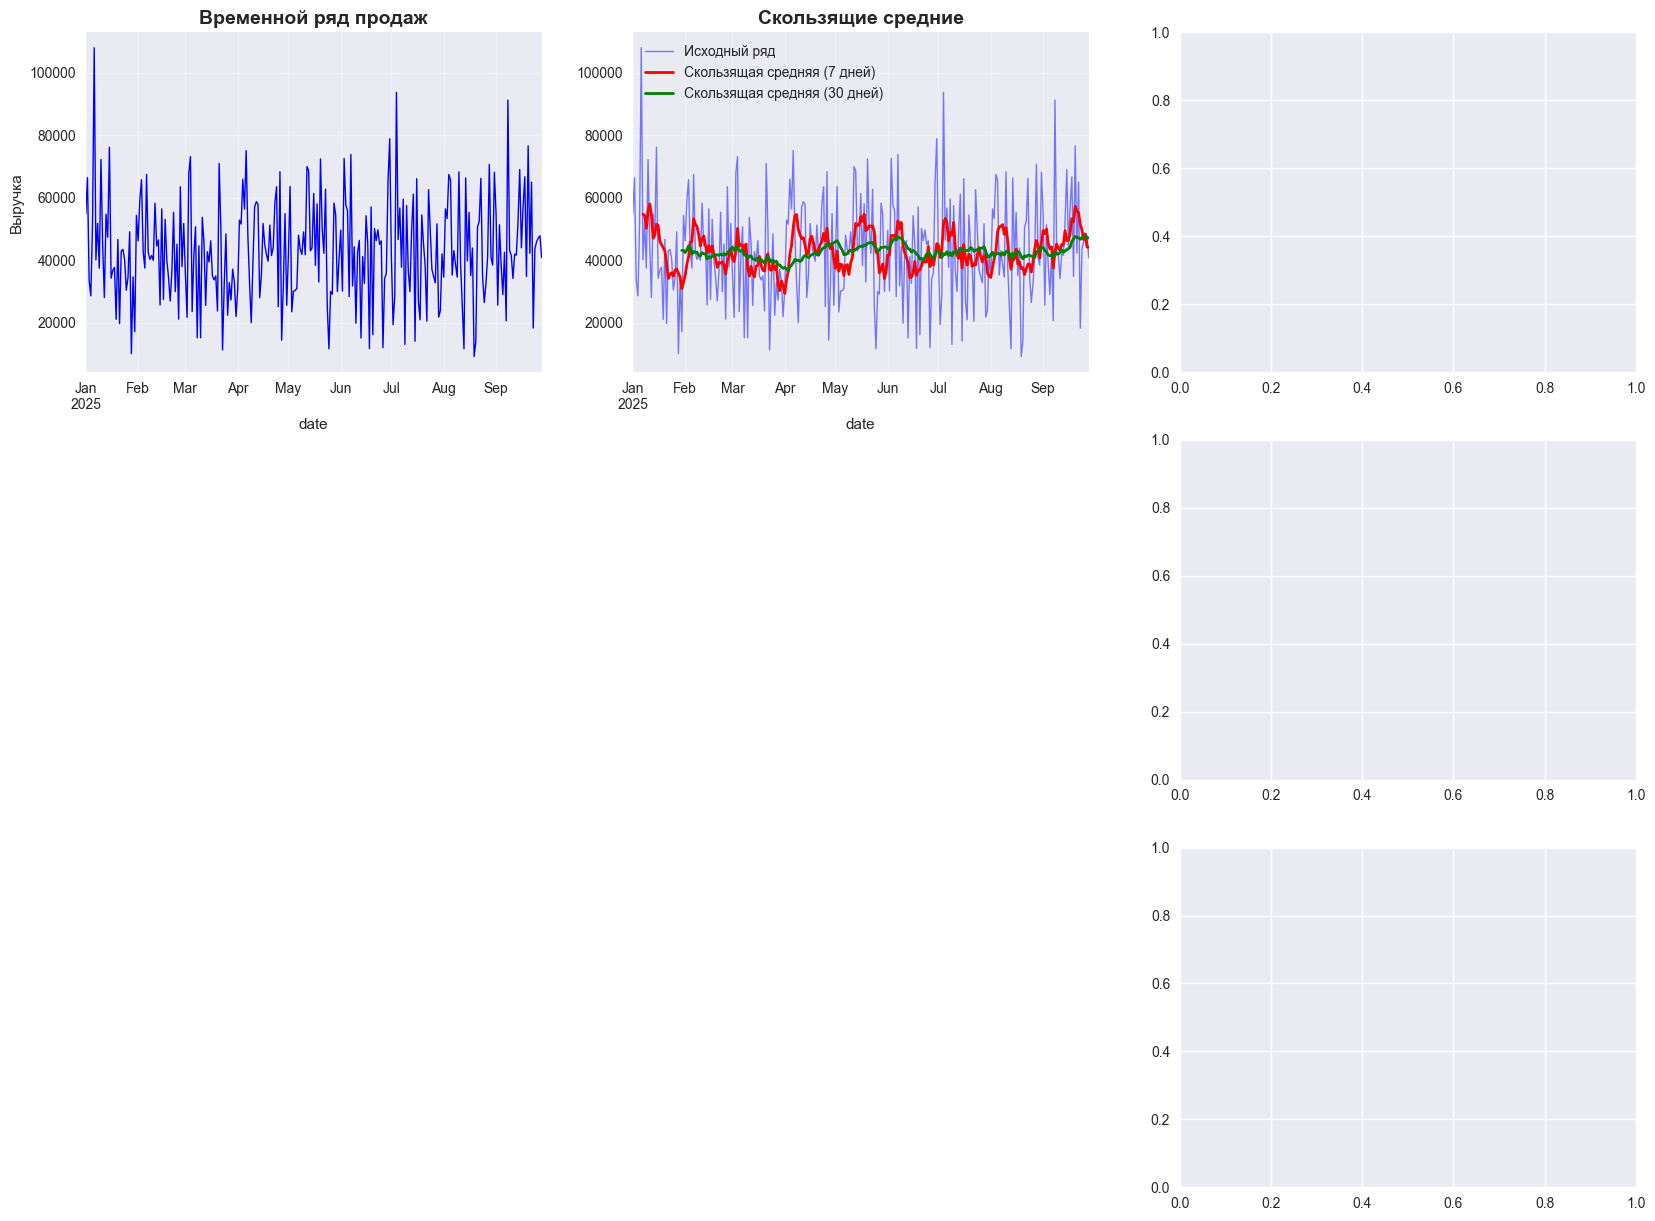

In [19]:
# 8. ВИЗУАЛИЗАЦИЯ АНАЛИЗА
print("\n" + "="*60)
print("КОМПЛЕКСНАЯ ВИЗУАЛИЗАЦИЯ АНАЛИЗА")
print("="*60)

ts_analyzer.plot_time_series_analysis()

In [20]:
# 9. ИНСАЙТЫ ДЛЯ ПРОГНОЗИРОВАНИЯ
print("\n" + "="*60)
print("ИНСАЙТЫ ДЛЯ ПРОГНОЗИРОВАНИЯ")
print("="*60)

forecast_insights = ts_analyzer.generate_forecast_insights()

if forecast_insights:
    print("🎯 РЕКОМЕНДАЦИИ ДЛЯ ПРОГНОЗИРОВАНИЯ:")
    print(f"• Достаточность данных: {forecast_insights['data_sufficiency']}")
    print(f"• Направление тренда: {forecast_insights['trend_direction']}")
    print(f"• Наличие сезонности: {forecast_insights['seasonality_present']}")
    print(f"• Волатильность: {forecast_insights['volatility']}")
    print(f"• Рекомендуемый метод: {forecast_insights['recommended_forecast_method']}")


ИНСАЙТЫ ДЛЯ ПРОГНОЗИРОВАНИЯ
🎯 РЕКОМЕНДАЦИИ ДЛЯ ПРОГНОЗИРОВАНИЯ:
• Достаточность данных: Достаточно
• Направление тренда: Нисходящий
• Наличие сезонности: Нет
• Волатильность: Умеренная
• Рекомендуемый метод: ARIMA


In [21]:
# 10. АНАЛИЗ РАЗЛИЧНЫХ МЕТРИК
print("\n" + "="*60)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТРИК")
print("="*60)

# Анализ разных метрик во времени
metrics = ['revenue', 'quantity', 'orders']
metrics_comparison = {}

for metric in metrics:
    ts_data = ts_analyzer.prepare_time_series(freq='W', metric=metric)
    if ts_data is not None:
        stats = ts_analyzer.analyze_trends()
        metrics_comparison[metric] = {
            'total': stats['total_value'],
            'mean': stats['mean_value'],
            'growth': stats['growth_rate']
        }

if metrics_comparison:
    comparison_df = pd.DataFrame(metrics_comparison).T
    print("Сравнение метрик во времени:")
    print(comparison_df.round(2))


СРАВНИТЕЛЬНЫЙ АНАЛИЗ МЕТРИК
Создан временной ряд: 39 периодов, частота: W, метрика: revenue
Создан временной ряд: 39 периодов, частота: W, метрика: quantity
Создан временной ряд: 39 периодов, частота: W, метрика: orders
Сравнение метрик во времени:
               total       mean  growth
revenue   11710723.0  300274.95   31.36
quantity      5941.0     152.33   30.89
orders        2354.0      60.36   39.53


In [22]:
# 11. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
print("\n" + "="*60)
print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ АНАЛИЗА")
print("="*60)

# Создаем папку для отчетов
ts_report_path = project_root / 'reports' / 'time_series'
ts_report_path.mkdir(parents=True, exist_ok=True)

# Сохраняем временные ряды
if daily_revenue is not None:
    daily_revenue.to_csv(ts_report_path / 'daily_revenue.csv')
    print("✓ Сохранен дневной временной ряд")

if weekly_analysis is not None:
    weekly_analysis.to_csv(ts_report_path / 'weekly_patterns.csv')
    print("✓ Сохранены недельные паттерны")

if decomposition:
    # Сохраняем компоненты декомпозиции
    decomposition_df = pd.DataFrame({
        'original': decomposition.observed,
        'trend': decomposition.trend,
        'seasonal': decomposition.seasonal,
        'residual': decomposition.resid
    })
    decomposition_df.to_csv(ts_report_path / 'decomposition.csv')
    print("✓ Сохранена декомпозиция")

if anomalies_analysis and anomalies_analysis['anomaly_count'] > 0:
    anomalies_analysis['anomalies'].to_csv(ts_report_path / 'anomalies.csv')
    print("✓ Сохранены аномалии")



СОХРАНЕНИЕ РЕЗУЛЬТАТОВ АНАЛИЗА
✓ Сохранен дневной временной ряд
✓ Сохранены недельные паттерны
✓ Сохранена декомпозиция
✓ Сохранены аномалии


In [23]:
# 12. ИТОГОВЫЕ ВЫВОДЫ
print("\n" + "="*60)
print("ИТОГОВЫЕ ВЫВОДЫ ПО АНАЛИЗУ ВРЕМЕННЫХ РЯДОВ")
print("="*60)

print("📊 КЛЮЧЕВЫЕ НАХОДКИ:")

if trend_analysis:
    growth_icon = "📈" if trend_analysis['growth_rate'] > 0 else "📉"
    print(f"• Тренд: {growth_icon} {trend_analysis['growth_rate']:+.1f}% за период")

if weekly_analysis is not None:
    best_day = weekly_analysis['revenue_sum'].idxmax()
    worst_day = weekly_analysis['revenue_sum'].idxmin()
    print(f"• Недельные паттерны: пик в {best_day}, спад в {worst_day}")

if seasonality_analysis and seasonality_analysis['significant_lags']:
    print(f"• Сезонность: обнаружена ({len(seasonality_analysis['significant_lags'])} значимых паттерна)")
else:
    print("• Сезонность: незначительная или отсутствует")

if anomalies_analysis:
    anomaly_status = "есть" if anomalies_analysis['anomaly_count'] > 0 else "нет"
    print(f"• Аномалии: {anomaly_status} ({anomalies_analysis['anomaly_count']} шт.)")

print(f"\n🎯 РЕКОМЕНДАЦИИ:")
print("• Использовать выявленные паттерны для планирования запасов")
print("• Учесть недельную цикличность в маркетинговых активностях")
print("• Мониторить аномалии для оперативного реагирования")


print("\n✅ АНАЛИЗ ВРЕМЕННЫХ РЯДОВ ЗАВЕРШЕН!")
print("📊 Созданы комплексные визуализации и инсайты")
print("📁 Сохранены отчеты в /reports/time_series/")


ИТОГОВЫЕ ВЫВОДЫ ПО АНАЛИЗУ ВРЕМЕННЫХ РЯДОВ
📊 КЛЮЧЕВЫЕ НАХОДКИ:
• Тренд: 📉 -25.5% за период
• Недельные паттерны: пик в Monday, спад в Tuesday
• Сезонность: незначительная или отсутствует
• Аномалии: есть (3 шт.)

🎯 РЕКОМЕНДАЦИИ:
• Использовать выявленные паттерны для планирования запасов
• Учесть недельную цикличность в маркетинговых активностях
• Мониторить аномалии для оперативного реагирования

✅ АНАЛИЗ ВРЕМЕННЫХ РЯДОВ ЗАВЕРШЕН!
📊 Созданы комплексные визуализации и инсайты
📁 Сохранены отчеты в /reports/time_series/
